# Feature Selection using Breast Cancer Dataset

## Objective
The objective of this experiment is to understand how selecting relevant features improves the performance of machine learning models.

We use the Breast Cancer dataset from scikit-learn and:
- Build a baseline Logistic Regression model using all features
- Apply feature selection techniques:
  - Filter Method (SelectKBest)
  - Wrapper Method (RFE)
  - Embedded Methods (L1 Regularization and Tree-based)
- Compare performance using accuracy

In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Shape:", df.shape)
print("Number of Features:", X.shape[1])
print("Target Classes:", data.target_names)

Shape: (569, 31)
Number of Features: 30
Target Classes: ['malignant' 'benign']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Baseline Model (All Features)

We train a Logistic Regression model using all available features.  
This serves as a reference model to evaluate the impact of feature selection techniques.

In [14]:
# Train baseline model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
baseline_acc = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.9736842105263158


## Feature Selection using Filter Method (SelectKBest)

In this method, features are selected based on statistical tests.  
We use ANOVA F-test to select the top 10 most relevant features.

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 10 features
selector = SelectKBest(score_func=f_classif, k=10)

X_train_k = selector.fit_transform(X_train, y_train)
X_test_k = selector.transform(X_test)

# Train model on selected features
model_k = LogisticRegression(max_iter=10000)
model_k.fit(X_train_k, y_train)

# Predictions
y_pred_k = model_k.predict(X_test_k)

# Accuracy
acc_k = accuracy_score(y_test, y_pred_k)

print("SelectKBest Accuracy:", acc_k)

SelectKBest Accuracy: 0.9736842105263158


In [16]:
selected_indices = selector.get_support(indices=True)
selected_features = df.columns[selected_indices]

print("Selected Features:\n", selected_features)

Selected Features:
 Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='object')


The SelectKBest method reduced the number of features from 30 to 10 while maintaining the same accuracy as the baseline model. This shows that many features were redundant and not necessary for prediction.

## Feature Selection using Wrapper Method (RFE)

Recursive Feature Elimination (RFE) selects features by recursively removing the least important ones based on model performance.

In [19]:
from sklearn.feature_selection import RFE

# Base model
model_rfe = LogisticRegression(max_iter=10000)

# Select top 10 features
rfe = RFE(model_rfe, n_features_to_select=10)

X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

# Train model
model_rfe.fit(X_train_rfe, y_train)

# Predictions
y_pred_rfe = model_rfe.predict(X_test_rfe)

# Accuracy
acc_rfe = accuracy_score(y_test, y_pred_rfe)

print("RFE Accuracy:", acc_rfe)

RFE Accuracy: 0.9736842105263158


In [21]:
selected_features_rfe = df.columns[:-1][rfe.support_]
print("RFE Selected Features:\n", selected_features_rfe)

RFE Selected Features:
 Index(['mean concave points', 'radius error', 'area error',
       'compactness error', 'worst radius', 'worst texture', 'worst perimeter',
       'worst area', 'worst concavity', 'worst concave points'],
      dtype='object')


RFE selected a different combination of features compared to SelectKBest while achieving the same accuracy. This shows that multiple feature subsets can yield similar performance, but RFE considers feature interactions, making it more robust.

## Embedded Method — L1 Regularization

In [37]:
model_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.01,   
    max_iter=10000
)

model_l1.fit(X_train, y_train)

selected_features = model_l1.coef_[0] != 0

X_train_l1 = X_train[:, selected_features]
X_test_l1 = X_test[:, selected_features]

model_l1.fit(X_train_l1, y_train)

y_pred_l1 = model_l1.predict(X_test_l1)

acc_l1 = accuracy_score(y_test, y_pred_l1)

print("L1 Accuracy:", acc_l1)
print("Number of selected features:", sum(selected_features))

L1 Accuracy: 0.9649122807017544
Number of selected features: 3


C:\Users\kaush\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kaush\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\kaush\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

In [38]:
selected_features_names = df.columns[:-1][selected_features]
print("L1 Selected Features:\n", selected_features_names)

L1 Selected Features:
 Index(['mean concave points', 'worst perimeter', 'worst concave points'], dtype='object')


With strong regularization (C = 0.01), L1 reduced the number of features significantly from 30 to 3. However, this led to a slight decrease in accuracy, indicating that too much feature reduction can cause loss of important information.

## Tree-Based Feature Selection

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Select features based on importance
selector_tree = SelectFromModel(rf, threshold="mean")

X_train_tree = selector_tree.transform(X_train)
X_test_tree = selector_tree.transform(X_test)

# Train Logistic Regression
model_tree = LogisticRegression(max_iter=10000)
model_tree.fit(X_train_tree, y_train)

y_pred_tree = model_tree.predict(X_test_tree)

acc_tree = accuracy_score(y_test, y_pred_tree)

print("Tree-based Accuracy:", acc_tree)
print("Number of selected features:", X_train_tree.shape[1])

Tree-based Accuracy: 0.9736842105263158
Number of selected features: 9


In [40]:
selected_tree_features = df.columns[:-1][selector_tree.get_support()]
print("Tree Selected Features:\n", selected_tree_features)

Tree Selected Features:
 Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concave points'],
      dtype='object')


Feature selection significantly reduces the number of input features while maintaining model performance. In this experiment, SelectKBest, RFE, and tree-based methods reduced the feature set without affecting accuracy. L1 regularization further reduced the features but resulted in a slight drop in accuracy.

Among all methods, tree-based and embedded methods provided the best balance between accuracy and computational efficiency. Feature selection helps in reducing model complexity, improving interpretability, and preventing overfitting.

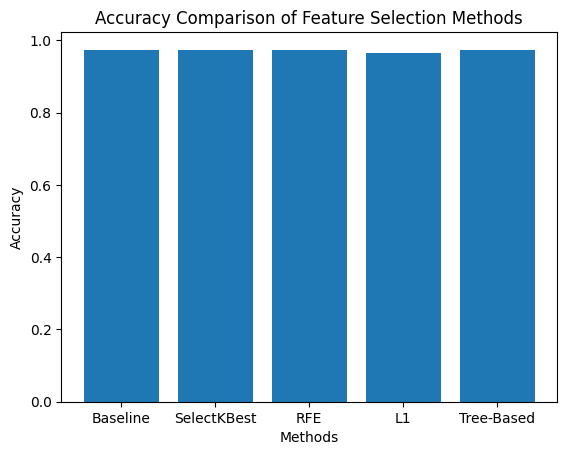

In [41]:
import matplotlib.pyplot as plt

methods = ["Baseline", "SelectKBest", "RFE", "L1", "Tree-Based"]
accuracies = [baseline_acc, acc_k, acc_rfe, acc_l1, acc_tree]

plt.figure()
plt.bar(methods, accuracies)

plt.title("Accuracy Comparison of Feature Selection Methods")
plt.xlabel("Methods")
plt.ylabel("Accuracy")

plt.show()

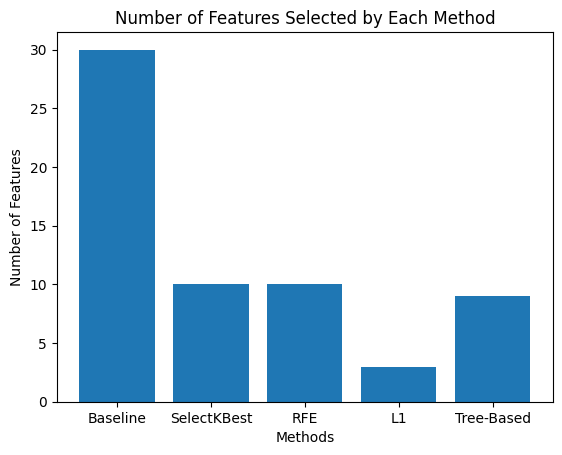

In [42]:
feature_counts = [
    X.shape[1],                  # Baseline (30)
    X_train_k.shape[1],          # SelectKBest (10)
    X_train_rfe.shape[1],        # RFE (10)
    X_train_l1.shape[1],         # L1 (~3)
    X_train_tree.shape[1]        # Tree (~9)
]

plt.figure()
plt.bar(methods, feature_counts)

plt.title("Number of Features Selected by Each Method")
plt.xlabel("Methods")
plt.ylabel("Number of Features")

plt.show()

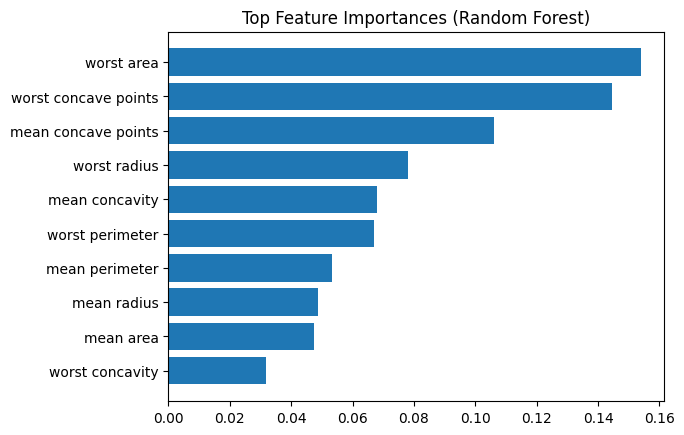

In [43]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]  # top 10 features

plt.figure()
plt.barh(range(len(indices)), importances[indices])

plt.yticks(range(len(indices)), df.columns[:-1][indices])
plt.title("Top Feature Importances (Random Forest)")

plt.show()

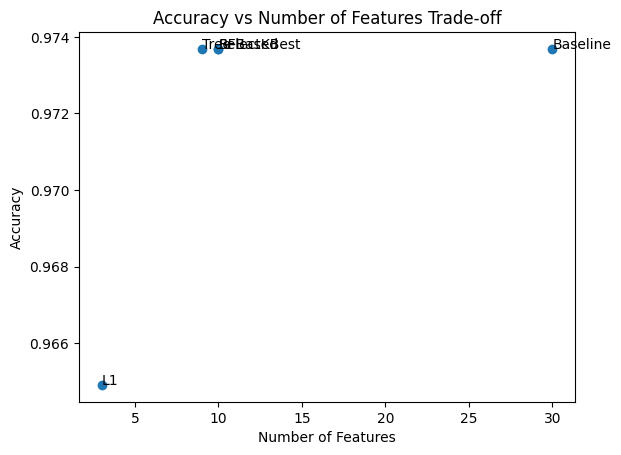

In [44]:
plt.figure()
plt.scatter(feature_counts, accuracies)

for i, txt in enumerate(methods):
    plt.annotate(txt, (feature_counts[i], accuracies[i]))

plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Features Trade-off")

plt.show()